In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
missing = train.drop("Cabin", axis = 1)
missing[missing.isna().any(axis=1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,Q
...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,S


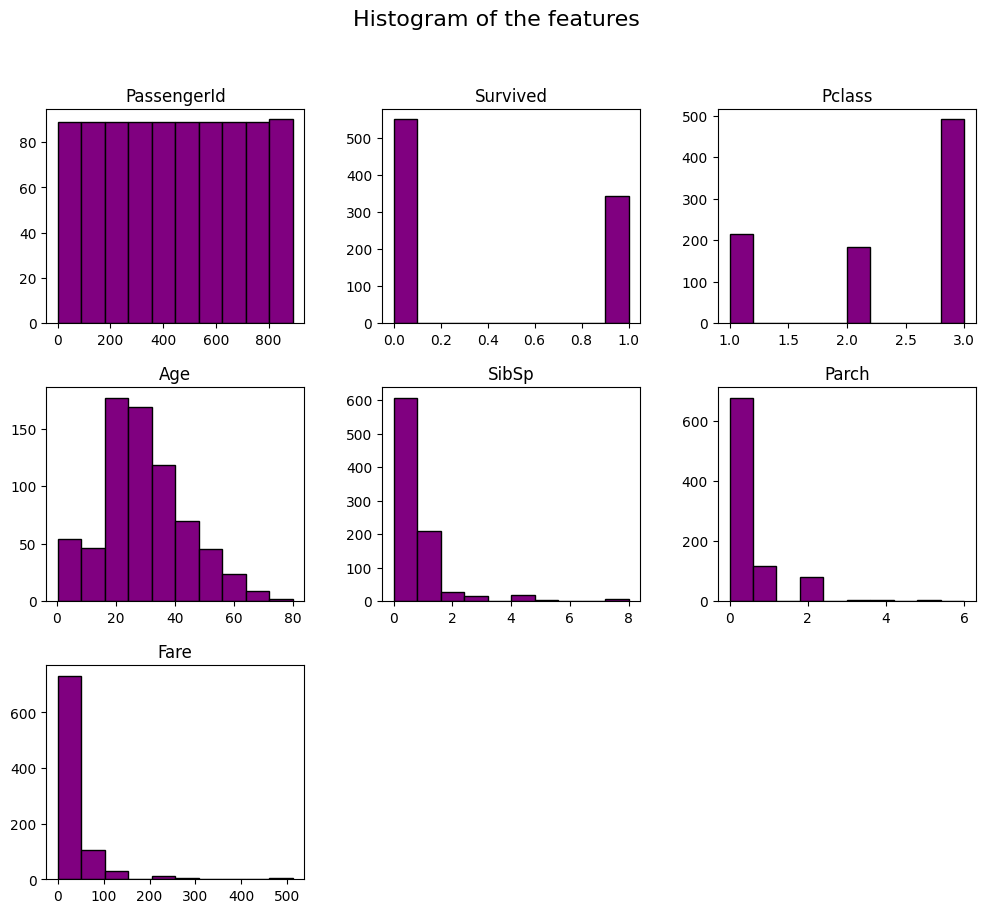

In [7]:
train.hist(figsize = (12,10),grid = False, color = "purple", edgecolor = "black")
plt.suptitle("Histogram of the features", fontsize = 16)
plt.show()

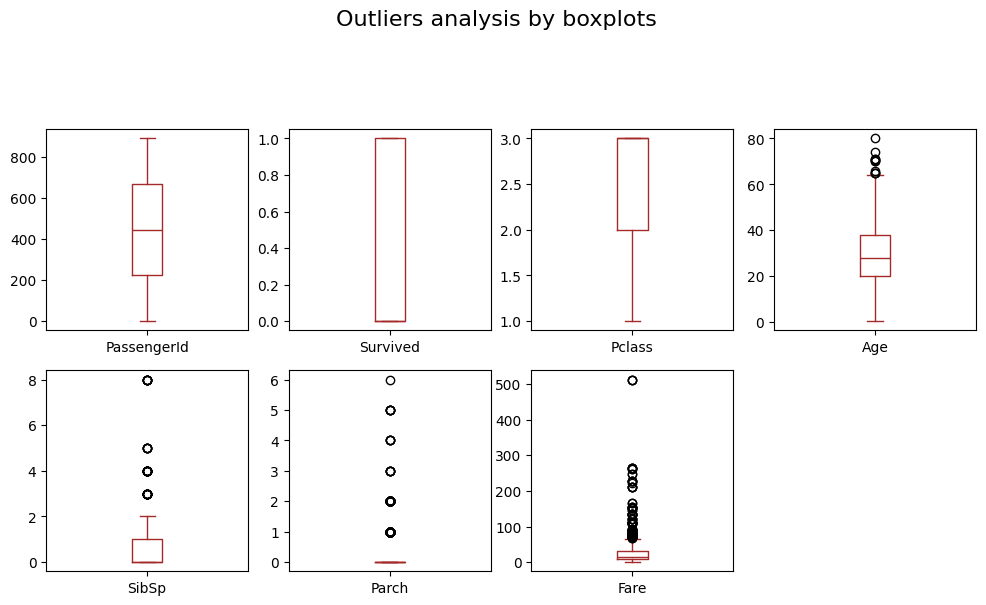

In [8]:
train.plot(kind = "box", subplots=  True, figsize = (12,12), layout = (4,4), color = "brown")
plt.suptitle("Outliers analysis by boxplots", fontsize = 16)
plt.show()

In [9]:
train_new = train.drop(["Name","Ticket", "Cabin"], axis = 1).set_index("PassengerId") 
# PassengerId is needed for identify and Name , ticket no.  has no connection with survival. 
# Cabin has a lot of missing values and it has so many categories that it has no significance
train_new.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


In [10]:
train_dummy = pd.get_dummies(train_new, columns = ["Sex", "Embarked"], drop_first = True, dtype = int)
train_dummy.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
1,0,3,22.0,1,0,7.2500,1,0,1
2,1,1,38.0,1,0,71.2833,0,0,0
3,1,3,26.0,0,0,7.9250,0,0,1
4,1,1,35.0,1,0,53.1000,0,0,1
5,0,3,35.0,0,0,8.0500,1,0,1


In [11]:
X = train_dummy.drop("Survived", axis = 1)
y = train_dummy["Survived"]

In [12]:
from sklearn.preprocessing import StandardScaler 

X["Age"] = X["Age"].fillna(X.Age.median()) 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.model_selection import train_test_split 
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train_lin, X_val_lin, y_train_lin, y_val_lin = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score 
    
def get_metric(y_true, y_pred): 
    acc = accuracy_score(y_true, y_pred) 
    pre = precision_score(y_true, y_pred) 
    rec = recall_score(y_true, y_pred) 
    f1  = f1_score(y_true, y_pred)

    return pd.DataFrame({"Accuracy": [acc], 
                        "Precision": [pre], 
                        "Recall": [rec], 
                        "F1-score": [f1]}).round(2)

In [15]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import cross_val_score 

log_model = LogisticRegression(random_state = 42) 
log_model.fit(X_train_lin, y_train_lin)


LogisticRegression(random_state=42)

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score

y_pred_log = log_model.predict(X_train_lin)
print(classification_report(y_train_lin, y_pred_log))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       444
           1       0.76      0.69      0.72       268

    accuracy                           0.80       712
   macro avg       0.79      0.78      0.78       712
weighted avg       0.80      0.80      0.80       712



In [17]:
cross_val_score(log_model, X_train_lin, y_train_lin, n_jobs = -1, scoring = "accuracy", cv = 5)

array([0.82517483, 0.8041958 , 0.78873239, 0.73943662, 0.79577465])

In [18]:
y_log = log_model.predict(X_val_lin)

In [19]:
print(classification_report(y_val_lin, y_log))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [20]:
from sklearn.tree import DecisionTreeClassifier 

dt = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [21]:
y_pred_dt = dt.predict(X_train) 
print(classification_report(y_train, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       444
           1       0.96      0.98      0.97       268

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



In [22]:
cross_val_score(dt, X_train, y_train, n_jobs = -1, scoring = "accuracy", cv = 5)

array([0.74825175, 0.72727273, 0.74647887, 0.74647887, 0.76056338])

In [23]:
y_pred = dt.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



In [24]:
get_metric(y_val, y_pred)

,Accuracy,Precision,Recall,F1-score
0,0.78,0.72,0.77,0.75


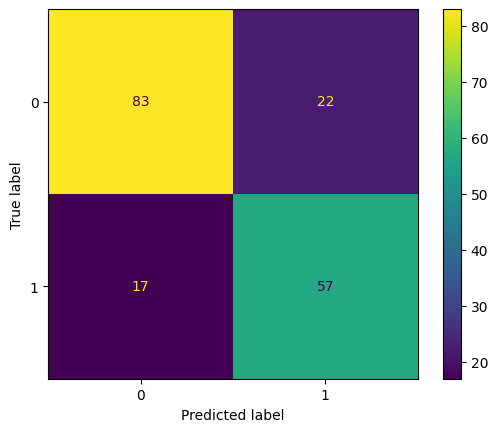

In [25]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred);

In [26]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV 


In [27]:
rnd = RandomForestClassifier(n_estimators = 300,
                             n_jobs = -1, random_state = 42, 
                             oob_score= True, class_weight = "balanced")
rnd.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       oob_score=True, random_state=42)

In [28]:
y_pred_train = rnd.predict(X_train) 
print(classification_report(y_train, y_pred_train
                           ))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       444
           1       0.97      0.97      0.97       268

    accuracy                           0.98       712
   macro avg       0.98      0.98      0.98       712
weighted avg       0.98      0.98      0.98       712



In [29]:
y_pred = rnd.predict(X_val) 
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [30]:
rnd.oob_score_

0.8019662921348315

In [31]:
X_train.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [32]:
rnd.estimator_params

('criterion',
 'max_depth',
 'min_samples_split',
 'min_samples_leaf',
 'min_weight_fraction_leaf',
 'max_features',
 'max_leaf_nodes',
 'min_impurity_decrease',
 'random_state',
 'ccp_alpha',
 'monotonic_cst')

In [33]:
param = {"max_leaf_nodes" : np.arange(10, 30, 5),
           "max_depth" : np.arange(5, 10, 1), 
           "n_estimators": [100, 200, 300],
            "max_features": [3, 4, 5, 6]}

grid = GridSearchCV(estimator = rnd, 
                    param_grid = param,
                    scoring = "roc_auc", 
                    cv = 5, n_jobs = -1)

grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300, n_jobs=-1,
                                              oob_score=True, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': array([5, 6, 7, 8, 9]),
                         'max_features': [3, 4, 5, 6],
                         'max_leaf_nodes': array([10, 15, 20, 25]),
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [34]:
grid.best_params_

{'max_depth': np.int64(9),
 'max_features': 4,
 'max_leaf_nodes': np.int64(25),
 'n_estimators': 100}

In [35]:
best_model = grid.best_estimator_

In [36]:
y_pred_train = best_model.predict(X_train) 
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       444
           1       0.89      0.82      0.85       268

    accuracy                           0.89       712
   macro avg       0.89      0.88      0.89       712
weighted avg       0.89      0.89      0.89       712



In [37]:
y_pred= best_model.predict(X_val) 
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [38]:
get_metric(y_val, y_pred)

,Accuracy,Precision,Recall,F1-score
0,0.83,0.81,0.76,0.78


In [39]:
best_model.oob_score_

0.8061797752808989

In [40]:
best_model.feature_importances_

array([0.1152783 , 0.14337001, 0.05053802, 0.02991933, 0.18520128,
       0.44563886, 0.00720043, 0.02285378])

In [41]:
pd.DataFrame({"features": best_model.feature_names_in_, 
              "scores"  : best_model.feature_importances_}).sort_values("scores", 
                                                                        ascending = False)

,features,scores
5,Sex_male,0.445639
4,Fare,0.185201
1,Age,0.143370
0,Pclass,0.115278
2,SibSp,0.050538
3,Parch,0.029919
7,Embarked_S,0.022854
6,Embarked_Q,0.007200


In [42]:

test_new = test.drop(["Name","Ticket", "Cabin"], axis = 1).set_index("PassengerId") 

X_test = pd.get_dummies(test_new, 
                        columns = ["Sex", "Embarked"],
                        drop_first = True, dtype = int)


In [43]:
X_test

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
PassengerId,,,,,,,,
892,3,34.5,0,0,7.8292,1,1,0
893,3,47.0,1,0,7.0000,0,0,1
894,2,62.0,0,0,9.6875,1,1,0
895,3,27.0,0,0,8.6625,1,0,1
896,3,22.0,1,1,12.2875,0,0,1
...,...,...,...,...,...,...,...,...
1305,3,NaN,0,0,8.0500,1,0,1
1306,1,39.0,0,0,108.9000,0,0,0
1307,3,38.5,0,0,7.2500,1,0,1


In [44]:
y_test = best_model.predict(X_test)

In [45]:
final_output = pd.DataFrame({"PassengerID": X_test.index, 
              "Survived": y_test})

In [46]:
final_output.to_csv("/kaggle/working/final_output.csv")